# **Bài thực hành 15. Rừng ngẫu nhiên (Random Forest)**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Data/credit_card_clean_3.csv')

print("Kích thước dữ liệu:", df.shape)

df.head()

Kích thước dữ liệu: (26664, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,EDUCATION_CAT,graduate school,high school,others,university
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,1,university,False,False,False,True
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,1000,1000,0,2000,1,university,False,False,False,True
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,1000,1000,1000,5000,0,university,False,False,False,True
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,1200,1100,1069,1000,0,university,False,False,False,True
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,10000,9000,689,679,0,university,False,False,False,True


In [13]:
print(df.info())

print("\nKiểm tra missing value")
print(df.isnull().sum())

print("\nKiểm tra dữ liệu trùng")
print("Số dòng trùng:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26664 entries, 0 to 26663
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          26664 non-null  object
 1   LIMIT_BAL                   26664 non-null  int64 
 2   SEX                         26664 non-null  int64 
 3   EDUCATION                   26664 non-null  int64 
 4   MARRIAGE                    26664 non-null  int64 
 5   AGE                         26664 non-null  int64 
 6   PAY_1                       26664 non-null  int64 
 7   PAY_2                       26664 non-null  int64 
 8   PAY_3                       26664 non-null  int64 
 9   PAY_4                       26664 non-null  int64 
 10  PAY_5                       26664 non-null  int64 
 11  PAY_6                       26664 non-null  int64 
 12  BILL_AMT1                   26664 non-null  int64 
 13  BILL_AMT2                   26664 non-null  in

In [17]:
target_col = 'default payment next month'

X = df.drop(columns=[target_col, 'ID'])
y = df[target_col]

print("Số lượng thuộc tính:", X.shape[1])

print("\nTên các thuộc tính:")
print(X.columns)

Số lượng thuộc tính: 28

Tên các thuộc tính:
Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'EDUCATION_CAT', 'graduate school', 'high school', 'others',
       'university'],
      dtype='object')



Phân bố nhãn:
default payment next month
0    20750
1     5914
Name: count, dtype: int64

Tỉ lệ phần trăm:
default payment next month
0    77.820282
1    22.179718
Name: proportion, dtype: float64


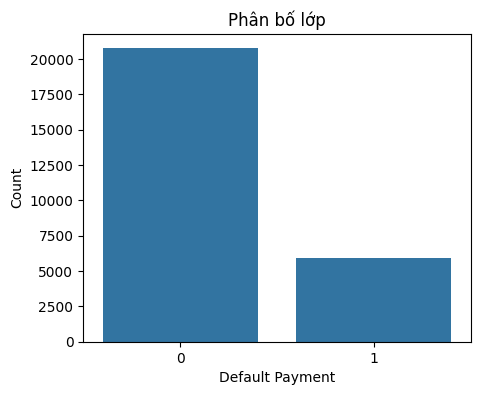

In [18]:
print("\nPhân bố nhãn:")
print(y.value_counts())

print("\nTỉ lệ phần trăm:")
print(y.value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))

sns.countplot(x=y)

plt.title("Phân bố lớp")
plt.xlabel("Default Payment")
plt.ylabel("Count")

plt.show()

In [25]:
target_col = 'default payment next month'

X = df.drop(columns=[
    target_col,
    'ID',
    'EDUCATION_CAT'
])

y = df[target_col]

print(X.dtypes)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

LIMIT_BAL          int64
SEX                int64
EDUCATION          int64
MARRIAGE           int64
AGE                int64
PAY_1              int64
PAY_2              int64
PAY_3              int64
PAY_4              int64
PAY_5              int64
PAY_6              int64
BILL_AMT1          int64
BILL_AMT2          int64
BILL_AMT3          int64
BILL_AMT4          int64
BILL_AMT5          int64
BILL_AMT6          int64
PAY_AMT1           int64
PAY_AMT2           int64
PAY_AMT3           int64
PAY_AMT4           int64
PAY_AMT5           int64
PAY_AMT6           int64
graduate school     bool
high school         bool
others              bool
university          bool
dtype: object

Shape X: (26664, 27)
Shape y: (26664,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Chuẩn hóa dữ liệu thành công")
print(X_scaled.shape)


Chuẩn hóa dữ liệu thành công
(26664, 27)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (18664, 27)
Test size: (8000, 27)


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=10,
    criterion='gini',
    max_depth=3,
    random_state=20,
    class_weight='balanced'
)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Predict probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

# ROC AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== RANDOM FOREST =====")

print("Accuracy:", round(acc_rf,4))
print("ROC AUC:", round(auc_rf,4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


===== RANDOM FOREST =====
Accuracy: 0.7864
ROC AUC: 0.7728

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      6226
           1       0.52      0.57      0.54      1774

    accuracy                           0.79      8000
   macro avg       0.70      0.71      0.70      8000
weighted avg       0.79      0.79      0.79      8000



In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    class_weight='balanced'
)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Predict probability
y_prob_dt = dt.predict_proba(X_test)[:,1]

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)

# ROC AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("\n===== DECISION TREE =====")

print("Accuracy:", round(acc_dt,4))
print("ROC AUC:", round(auc_dt,4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


===== DECISION TREE =====
Accuracy: 0.767
ROC AUC: 0.7549

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      6226
           1       0.48      0.58      0.52      1774

    accuracy                           0.77      8000
   macro avg       0.68      0.70      0.68      8000
weighted avg       0.79      0.77      0.77      8000



In [33]:
from sklearn.model_selection import GridSearchCV

rf_params_ex = {
    'n_estimators': list(range(10,110,10))
}

cv_rf_ex = GridSearchCV(
    estimator=rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    cv=4,
    verbose=1,
    return_train_score=True,
    n_jobs=-1
)

# Train GridSearch
cv_rf_ex.fit(X_train, y_train)

print("\n===== GRID SEARCH =====")

print("Best Parameters:")
print(cv_rf_ex.best_params_)

print("\nBest ROC AUC:")
print(cv_rf_ex.best_score_)

Fitting 4 folds for each of 10 candidates, totalling 40 fits

===== GRID SEARCH =====
Best Parameters:
{'n_estimators': 30}

Best ROC AUC:
0.7659750245138148


In [34]:
cv_rf_ex_results_df = pd.DataFrame(
    cv_rf_ex.cv_results_
)

cv_rf_ex_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
0,0.432552,0.078739,0.019516,0.010845,10,{'n_estimators': 10},0.757907,0.757060,0.762282,0.768993,0.761560,0.004727,10,0.765854,0.768314,0.766378,0.765626,0.766543,0.001058
1,0.613206,0.030908,0.020539,0.008980,20,{'n_estimators': 20},0.761603,0.760989,0.765379,0.773349,0.765330,0.004925,3,0.770519,0.770945,0.769824,0.769524,0.770203,0.000560
2,0.904548,0.052194,0.019795,0.007818,30,{'n_estimators': 30},0.761799,0.762221,0.765878,0.774002,0.765975,0.004898,1,0.771518,0.771903,0.771105,0.771136,0.771415,0.000325
3,1.271139,0.115296,0.031735,0.009253,40,{'n_estimators': 40},0.761987,0.761748,0.763876,0.772598,0.765052,0.004434,5,0.771624,0.771503,0.770996,0.770237,0.771090,0.000546
4,1.550190,0.132801,0.035299,0.015273,50,{'n_estimators': 50},0.761975,0.761132,0.764596,0.774491,0.765549,0.005318,2,0.771554,0.771969,0.771121,0.770708,0.771338,0.000471


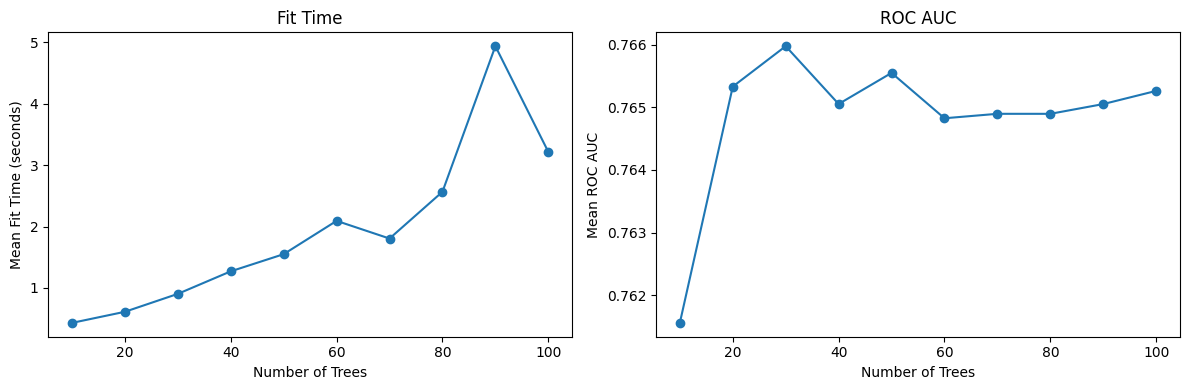

In [35]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12,4)
)

# Mean fit time
axs[0].plot(
    cv_rf_ex_results_df['param_n_estimators'],
    cv_rf_ex_results_df['mean_fit_time'],
    '-o'
)

axs[0].set_xlabel('Number of Trees')
axs[0].set_ylabel('Mean Fit Time (seconds)')
axs[0].set_title('Fit Time')

# ROC AUC
axs[1].plot(
    cv_rf_ex_results_df['param_n_estimators'],
    cv_rf_ex_results_df['mean_test_score'],
    '-o'
)

axs[1].set_xlabel('Number of Trees')
axs[1].set_ylabel('Mean ROC AUC')
axs[1].set_title('ROC AUC')

plt.tight_layout()

plt.show()

* Khi số lượng cây tăng → thời gian train tăng gần tuyến tính
* ROC AUC tăng mạnh ở giai đoạn đầu
* Sau khoảng 30 cây mô hình bắt đầu ổn định
* Thêm quá nhiều cây không cải thiện đáng kể hiệu năng

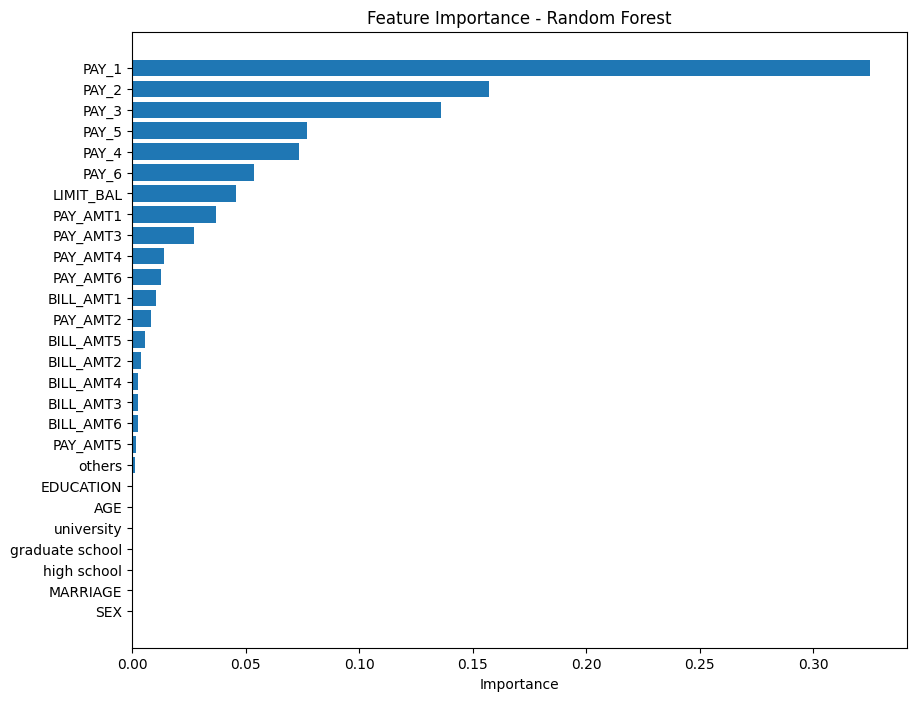


TOP 10 IMPORTANT FEATURES
      Feature  Importance
5       PAY_1    0.325018
6       PAY_2    0.157389
7       PAY_3    0.136293
9       PAY_5    0.077264
8       PAY_4    0.073386
10      PAY_6    0.053831
0   LIMIT_BAL    0.045888
17   PAY_AMT1    0.036900
19   PAY_AMT3    0.027311
20   PAY_AMT4    0.014155


In [36]:
feat_imp_df = pd.DataFrame({
'Feature': X.columns,
'Importance': cv_rf_ex.best_estimator_.feature_importances_
})

feat_imp_df = feat_imp_df.sort_values(
'Importance',
ascending=True
)

# Vẽ biểu đồ

plt.figure(figsize=(10,8))

plt.barh(
feat_imp_df['Feature'],
feat_imp_df['Importance']
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance")

plt.show()

# Top thuộc tính quan trọng nhất

print("\nTOP 10 IMPORTANT FEATURES")

print(
feat_imp_df.sort_values(
'Importance',
ascending=False
).head(10)
)

NHẬN XÉT:

- Các thuộc tính PAY_1, PAY_2, PAY_3 thường có độ quan trọng cao nhất.
- Các biến lịch sử thanh toán ảnh hưởng mạnh đến khả năng vỡ nợ.
- Các biến BILL_AMT và PAY_AMT cũng có đóng góp lớn.
- Những thuộc tính có Importance thấp đóng góp ít cho mô hình.


In [37]:
# Tối ưu:
# - n_estimators
# - max_depth

rf_params_2 = {
    'n_estimators': [10, 50, 100, 150, 200],
    'max_depth': [3, 6, 9, 12]
}

rf_2 = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

cv_rf_2 = GridSearchCV(
    estimator=rf_2,
    param_grid=rf_params_2,
    scoring='roc_auc',
    cv=4,
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)

# Train GridSearch
cv_rf_2.fit(X_train, y_train)

print("\n===== GRID SEARCH 2 PARAMETERS =====")

print("Best Parameters:")
print(cv_rf_2.best_params_)

print("\nBest ROC AUC:")
print(cv_rf_2.best_score_)


Fitting 4 folds for each of 20 candidates, totalling 80 fits

===== GRID SEARCH 2 PARAMETERS =====
Best Parameters:
{'max_depth': 9, 'n_estimators': 200}

Best ROC AUC:
0.7728645041290978


In [40]:
results_2_df = pd.DataFrame(
cv_rf_2.cv_results_
)

results_2_df.head()

print("Best Parameters:")
print(cv_rf_2.best_params_)

print("\nBest ROC AUC:")
print(cv_rf_2.best_score_)

Best Parameters:
{'max_depth': 9, 'n_estimators': 200}

Best ROC AUC:
0.7728645041290978


param_n_estimators       10        50        100       150       200
param_max_depth                                                     
3                   0.763426  0.763876  0.764274  0.764439  0.764595
6                   0.770781  0.772164  0.772051  0.772419  0.772448
9                   0.760886  0.771212  0.772256  0.772688  0.772865
12                  0.755306  0.766667  0.768141  0.769348  0.770030


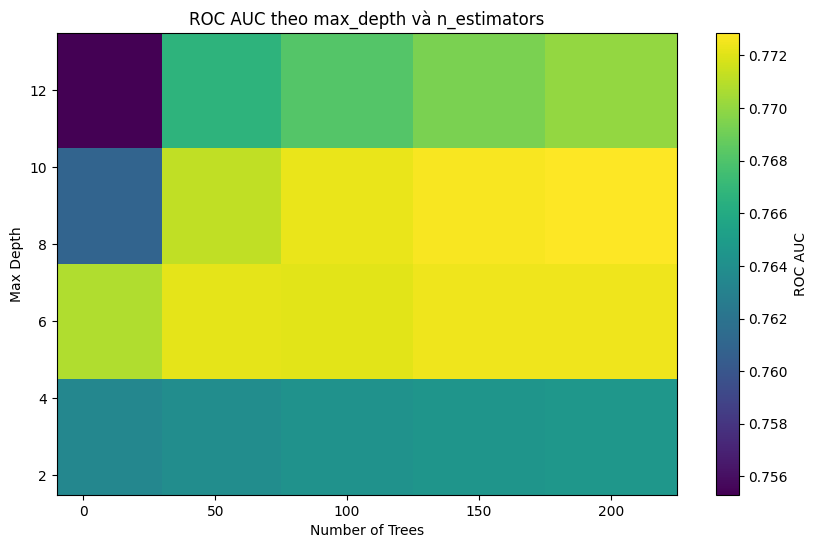

In [41]:
pivot_auc = results_2_df.pivot_table(
values='mean_test_score',
index='param_max_depth',
columns='param_n_estimators'
)

print(pivot_auc)

# =========================================================

# VẼ HEATMAP / PCOLORMESH

# =========================================================

plt.figure(figsize=(10,6))

plt.pcolormesh(
pivot_auc.columns,
pivot_auc.index,
pivot_auc.values,
shading='auto'
)

plt.colorbar(label='ROC AUC')
plt.xlabel('Number of Trees')
plt.ylabel('Max Depth')
plt.title('ROC AUC theo max_depth và n_estimators')
plt.show()

NHẬN XÉT:

* Khi tăng max_depth, mô hình học được nhiều đặc trưng hơn.

* Khi tăng n_estimators, mô hình ổn định hơn.

* ROC AUC cao nhất đạt được tại:

  * max_depth = 9
  * n_estimators = 200

* Sau mức này, hiệu năng cải thiện không đáng kể
  nhưng thời gian train tăng mạnh.

In [42]:
# =========================================================
# XÂY DỰNG RANDOM FOREST TỐI ƯU NHẤT
# =========================================================

best_rf = RandomForestClassifier(
n_estimators=200,
max_depth=9,
random_state=42,
class_weight='balanced',
n_jobs=-1
)

# Train model

best_rf.fit(X_train, y_train)

# Predict

y_pred_best_rf = best_rf.predict(X_test)

# Predict probability

y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

# Accuracy

acc_best_rf = accuracy_score(y_test, y_pred_best_rf)

# ROC AUC

auc_best_rf = roc_auc_score(y_test, y_prob_best_rf)

print("\n===== BEST RANDOM FOREST =====")

print("Accuracy:", round(acc_best_rf,4))

print("ROC AUC:", round(auc_best_rf,4))

print("\nClassification Report:")

print(classification_report(y_test, y_pred_best_rf))


===== BEST RANDOM FOREST =====
Accuracy: 0.7871
ROC AUC: 0.7834

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      6226
           1       0.52      0.56      0.54      1774

    accuracy                           0.79      8000
   macro avg       0.70      0.71      0.70      8000
weighted avg       0.79      0.79      0.79      8000



In [44]:
# =========================================================
# LOGISTIC REGRESSION
# =========================================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
max_iter=2000,
class_weight='balanced'
)

# Train

lr.fit(X_train, y_train)

# Predict

y_pred_lr = lr.predict(X_test)

# Predict probability

y_prob_lr = lr.predict_proba(X_test)[:,1]

# Accuracy

acc_lr = accuracy_score(y_test, y_pred_lr)

# ROC AUC

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("\n===== LOGISTIC REGRESSION =====")

print("Accuracy:", round(acc_lr,4))

print("ROC AUC:", round(auc_lr,4))


===== LOGISTIC REGRESSION =====
Accuracy: 0.6903
ROC AUC: 0.7309


In [45]:
# =========================================================
# DECISION TREE CUỐI
# =========================================================

dt_final = DecisionTreeClassifier(
max_depth=9,
random_state=42,
class_weight='balanced'
)

# Train

dt_final.fit(X_train, y_train)

# Predict

y_pred_dt_final = dt_final.predict(X_test)

# Predict probability

y_prob_dt_final = dt_final.predict_proba(X_test)[:,1]

# Accuracy

acc_dt_final = accuracy_score(y_test, y_pred_dt_final)

# ROC AUC

auc_dt_final = roc_auc_score(y_test, y_prob_dt_final)

print("\n===== DECISION TREE =====")

print("Accuracy:", round(acc_dt_final,4))

print("ROC AUC:", round(auc_dt_final,4))


===== DECISION TREE =====
Accuracy: 0.7384
ROC AUC: 0.7265


In [46]:
# =========================================================

# SO SÁNH 3 MÔ HÌNH

# =========================================================

final_compare = pd.DataFrame({
'Model': [
'Decision Tree',
'Logistic Regression',
'Random Forest'
],
'Accuracy': [
acc_dt_final,
acc_lr,
acc_best_rf
],
'ROC AUC': [
auc_dt_final,
auc_lr,
auc_best_rf
]
})

print("\n===== MODEL COMPARISON =====")

print(final_compare)


===== MODEL COMPARISON =====
                 Model  Accuracy   ROC AUC
0        Decision Tree  0.738375  0.726540
1  Logistic Regression  0.690250  0.730888
2        Random Forest  0.787125  0.783376


NHẬN XÉT:

* Random Forest cho ROC AUC cao nhất.
* Decision Tree dễ bị overfitting hơn.
* Logistic Regression đơn giản nhưng hiệu năng thấp hơn.
* Random Forest là mô hình phù hợp nhất cho bài toán dự đoán vỡ nợ.

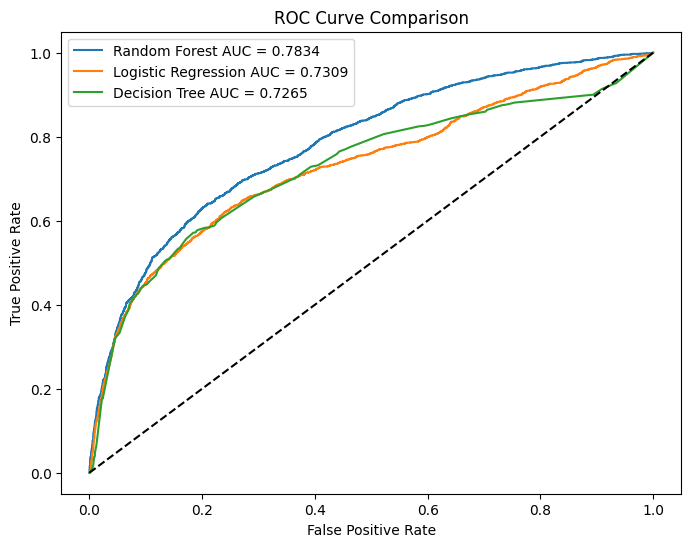

In [47]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(
y_test,
y_prob_best_rf
)

fpr_lr, tpr_lr, _ = roc_curve(
y_test,
y_prob_lr
)

fpr_dt, tpr_dt, _ = roc_curve(
y_test,
y_prob_dt_final
)

plt.figure(figsize=(8,6))

plt.plot(
fpr_rf,
tpr_rf,
label=f'Random Forest AUC = {auc_best_rf:.4f}'
)

plt.plot(
fpr_lr,
tpr_lr,
label=f'Logistic Regression AUC = {auc_lr:.4f}'
)

plt.plot(
fpr_dt,
tpr_dt,
label=f'Decision Tree AUC = {auc_dt_final:.4f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

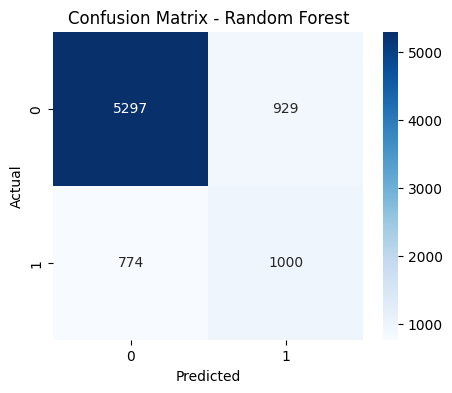

In [48]:
# CONFUSION MATRIX RANDOM FOREST
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
y_test,
y_pred_best_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Random Forest")

plt.show()


KẾT LUẬN:

* Trong bài thực hành này, mô hình Random Forest đã được xây dựng
  để dự đoán khách hàng có khả năng vỡ nợ hay không.

* Sau quá trình GridSearchCV, mô hình tối ưu đạt được với:

  * n_estimators = 200
  * max_depth = 9

* Random Forest cho kết quả tốt nhất so với:

  * Decision Tree
  * Logistic Regression

* ROC AUC đạt giá trị cao nhất cho thấy khả năng phân biệt
  giữa khách hàng vỡ nợ và không vỡ nợ khá tốt.

* Việc tăng số lượng cây giúp mô hình ổn định hơn,
  giảm hiện tượng overfitting của cây quyết định đơn lẻ.

* Feature Importance cho thấy:

  * Các biến PAY_1, PAY_2, PAY_3 là các thuộc tính quan trọng nhất.
  * Lịch sử thanh toán ảnh hưởng mạnh đến nguy cơ vỡ nợ.

* Random Forest là mô hình phù hợp cho bài toán
  phát hiện khách hàng có nguy cơ không thanh toán.